# Clasificación de textos según los Objetivos de Desarrollo Sostenible

**Microproyecto 2. Machine Learning No Supervisado, MAIA, Universidad de los Andes**

En este notebook construimos una solución de procesamiento de lenguaje natural que asigna a un texto en español el Objetivo de Desarrollo Sostenible (ODS) con el que guarda mayor relación semántica. Partimos de una representación de bolsa de palabras con pesado TF-IDF, reducimos la dimensionalidad con análisis semántico latente (LSA) y entrenamos un clasificador sobre el espacio reducido. En general, seguiremos los siguientes pasos:

1. [Importar las librerías necesarias.](#1.-Importación-de-librerías-requeridas)
2. [Cargar y explorar el conjunto de datos.](#2.-Carga-de-datos)
3. [Procesar los textos con un pipeline de TF-IDF y LSA.](#3.-Procesamiento-de-los-textos)
4. [Interpretar los tópicos del modelo LSA.](#4.-Interpretación-de-los-tópicos-del-LSA)
5. [Entrenar un modelo de referencia con regresión logística.](#5.-Modelo-de-referencia:-regresión-logística)
6. [Entrenar un perceptrón multicapa.](#6.-Clasificación-con-un-perceptrón-multicapa)
7. [Realizar una búsqueda de hiperparámetros.](#7.-Búsqueda-de-hiperparámetros)
8. [Evaluar el modelo final.](#8.-Evaluación-del-modelo-final)

## 1. Importación de librerías requeridas

Importaremos las librerías `pandas`, `numpy`, `nltk`, `scikit-learn`, `keras` y `keras-tuner`. Para la preparación de los textos y la reducción de la dimensionalidad utilizaremos:

* [`TfidfVectorizer()`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html): clase para construir la bolsa de palabras con pesado TF-IDF.
* [`TruncatedSVD()`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html): clase para aplicar la descomposición en valores singulares sin centrar los datos, que es lo que define el análisis semántico latente.
* [`Pipeline()`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): clase para encadenar las transformaciones en un solo objeto.

Y para el clasificador:

* [`Sequential()`](https://keras.io/api/models/sequential/): clase para definir modelos basados en capas lineales.
* [`Dense()`](https://keras.io/api/layers/core_layers/dense/): clase para definir una capa de neuronas densamente conectadas.
* [`Input()`](https://keras.io/api/layers/core_layers/input/): función para definir un tensor de entrada para el modelo.
* [`RandomSearch()`](https://keras.io/keras_tuner/api/tuners/random/): clase de `keras-tuner` para la búsqueda aleatoria de hiperparámetros. Puedes instalarla con `pip install keras-tuner`.

Fijaremos la semilla en `numpy`, `random` y `tensorflow` para que los resultados sean reproducibles.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import random
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras_tuner as kt

from src.DataPreprocessing import NOMBRES_ODS

SEED = 32
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga de datos

Realizaremos la carga de datos usando la función de Pandas `read_excel()`, especificando la ruta del archivo. El conjunto tiene una sola hoja con dos columnas: `textos`, con el texto en español, y `ODS`, con la etiqueta que le asignaron los voluntarios:

In [2]:
df = pd.read_excel(RAIZ / 'data' / 'Datos_textosODS.xlsx')
df

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5
...,...,...
9651,Esto implica que el tiempo de las mujeres en e...,5
9652,"Sin embargo, estas fallas del mercado implican...",3
9653,El hecho de hacerlo y cómo hacerlo dependerá e...,9
9654,"Esto se destacó en el primer estudio de caso, ...",6


### Tratamiento de nulos y duplicados

Antes de procesar los textos revisaremos la cantidad de datos nulos y duplicados:

In [3]:
print(f'Nulos por columna:\n{df.isna().sum()}')
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'Textos duplicados: {df["textos"].duplicated().sum()}')

Nulos por columna:
textos    0
ODS       0
dtype: int64

Filas duplicadas: 0
Textos duplicados: 0


El conjunto no tiene nulos ni repeticiones, así que no hay que eliminar filas.

### Distribución de la variable objetivo

Veremos cuántos textos hay por cada ODS, porque de ahí dependen dos decisiones posteriores: cómo partir los datos y con qué métrica evaluar el modelo:

In [4]:
conteo = df['ODS'].value_counts().sort_index()
conteo

ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64

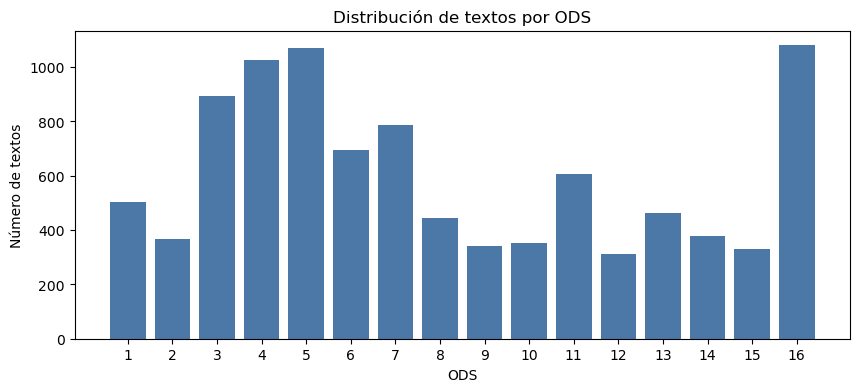

Clases presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Razón entre la clase mayoritaria y la minoritaria: 3.46


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(conteo.index, conteo.values, color='#4C78A8')
ax.set_xticks(conteo.index)
ax.set_xlabel('ODS')
ax.set_ylabel('Número de textos')
ax.set_title('Distribución de textos por ODS')
plt.show()

print(f'Clases presentes: {sorted(df["ODS"].unique().tolist())}')
print(f'Razón entre la clase mayoritaria y la minoritaria: {conteo.max() / conteo.min():.2f}')

**Observaciones:**

1.Hay 16 clases y no 17. El enunciado habla de los 17 ODS, pero el ODS 17 (*Alianzas para lograr los objetivos*) no aparece en los datos. Por eso las etiquetas de los reportes las derivaremos de los datos en lugar de fijarlas en 17.

2. Las clases están desbalanceadas, el ODS 16 tiene 1.080 textos y el ODS 12 tiene 312, esto causa que las particiones serán estratificadas para que cada subconjunto conserve la proporción original de clases, y la métrica principal será el F1 macro, que promedia el F1 de cada clase dándoles el mismo peso. La exactitud premiaría a un modelo que acierte en las clases grandes e ignore las pequeñas.

### Longitud de los textos

La longitud también nos sirve para elegir los parámetros del vectorizador más adelante:

In [6]:
df['textos'].str.split().str.len().describe().round(1)

count    9656.0
mean      111.0
std        37.1
min        24.0
25%        82.0
50%       105.0
75%       135.0
max       268.0
Name: textos, dtype: float64

### Separación de la variable objetivo

Separaremos la variable objetivo de los textos, que se convertirán en las variables descriptoras:

In [7]:
x = df['textos']
y = df['ODS']

x

0       "Aprendizaje" y "educación" se consideran sinó...
1       No dejar clara la naturaleza de estos riesgos ...
2       Como resultado, un mayor y mejorado acceso al ...
3       Con el Congreso firmemente en control de la ju...
4       Luego, dos secciones finales analizan las impl...
                              ...                        
9651    Esto implica que el tiempo de las mujeres en e...
9652    Sin embargo, estas fallas del mercado implican...
9653    El hecho de hacerlo y cómo hacerlo dependerá e...
9654    Esto se destacó en el primer estudio de caso, ...
9655    Aunque existen programas para convertirse espe...
Name: textos, Length: 9656, dtype: object

### Partición en entrenamiento, validación y prueba

Como el entrenamiento de la red neuronal usa un conjunto de validación para evaluar la pérdida al final de cada época, dividiremos los datos en tres partes: entrenamiento (70%), validación (15%) y prueba (15%). Usaremos el parámetro `stratify` para conservar la proporción de clases en cada subconjunto.

La partición se hace **antes** de ajustar cualquier transformación. Si el TF-IDF o el SVD se ajustaran con todos los datos, el vocabulario y las componentes latentes incorporarían información de los textos de prueba y la evaluación quedaría contaminada

In [8]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=SEED, stratify=y)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Entrenamiento: {len(x_train)}')
print(f'Validación: {len(x_val)}')
print(f'Prueba: {len(x_test)}')

Entrenamiento: 6759
Validación: 1448
Prueba: 1449


## 3. Procesamiento de los textos

El siguiente paso es obtener una representación numérica de los textos. Lo haremos en dos etapas encadenadas en un `Pipeline`: primero la bolsa de palabras con pesado TF-IDF y después la reducción de la dimensionalidad con `TruncatedSVD`.

### Procesamiento de textos

Definiremos la función `procesar_texto()` para realizar todos los pasos del procesamiento: paso a minúsculas, tokenización, eliminación de palabras vacías y stemming. A diferencia del tutorial de perceptrón multicapa, que trabaja con tweets en inglés, aquí las palabras vacías son las del español y el stemmer es `SnowballStemmer('spanish')`. El `PorterStemmer` del tutorial solo funciona con inglés.

El tokenizador `RegexpTokenizer(r'\w+')` descarta signos de puntuación y números sueltos, y el stemming reduce las variantes de una misma raíz (*educación*, *educativo*, *educar*) a un único término, lo que baja el tamaño del vocabulario y agrupa las ocurrencias dispersas:

In [9]:
tokenizador = RegexpTokenizer(r'\w+')
stemmer = SnowballStemmer('spanish')
palabras_vacias = set(stopwords.words('spanish'))


def procesar_texto(texto):
    tokens = tokenizador.tokenize(str(texto).lower())
    tokens = [palabra for palabra in tokens if palabra not in palabras_vacias]
    tokens = [stemmer.stem(palabra) for palabra in tokens]
    return ' '.join(tokens)

Podemos ver el efecto de la función sobre uno de los textos de entrenamiento. Este es el original:

In [10]:
x_train.iloc[0]

'La proporción de proveedores privados de atención primaria ha aumentado rápidamente en los últimos años. Algunas regiones permitieron el establecimiento sin restricciones de proveedores acreditados hace ya diez años, y en 2010 este derecho a establecer libremente nuevas clínicas de atención primaria con reembolso público se convirtió en ley nacional. Los médicos públicos y privados (incluidos los especialistas hospitalarios) y el resto del personal sanitario son predominantemente asalariados. La atención altamente especializada, que requiere los equipos técnicos más avanzados, se concentra en siete hospitales universitarios públicos.'

Y este es el resultado del procesamiento:

In [11]:
procesar_texto(x_train.iloc[0])

'proporcion proveedor priv atencion primari aument rapid ultim años region permit establec restriccion proveedor acredit hac diez años 2010 derech establec librement nuev clinic atencion primari reembols public convirt ley nacional medic public priv inclu especial hospitalari rest personal sanitari predomin asalari atencion alt especializ requier equip tecnic avanz concentr siet hospital universitari public'

### Construcción del pipeline de preparación

Ahora encadenaremos las transformaciones en un objeto de la clase `Pipeline()`. El pipeline tiene dos pasos:

* `tfidf`: un `TfidfVectorizer()` con el parámetro `preprocessor`, que aplica `procesar_texto()` a cada documento antes de construir la bolsa de palabras. Usamos TF-IDF en lugar de conteos simples porque el pesado divide la frecuencia de cada término por el número de documentos en que aparece: un término que está en casi todos los textos aporta poco para distinguir entre ODS y queda con un peso bajo. Con `min_df=5` descartamos los términos que aparecen en menos de cinco documentos, que en su mayoría son errores de traducción o palabras demasiado específicas, y con `max_df=0.8` los que aparecen en más del 80% de los documentos. El parámetro `sublinear_tf=True` aplica una escala logarítmica a la frecuencia, adecuada cuando los textos son largos, como aquí (una media de 111 palabras).
* `lsa`: un `TruncatedSVD()` sobre la matriz TF-IDF. El SVD truncado opera directamente sobre la matriz dispersa y sin centrar los datos, que es justamente lo que define el análisis semántico latente. Un PCA obligaría a densificar la matriz, con un costo de memoria mucho mayor.

Empezaremos con 20 componentes, el extremo superior del rango sugerido en el enunciado, y en la sección 5 compararemos 10, 15 y 20 con el modelo de referencia:

In [12]:
preparacion = Pipeline([
    ('tfidf', TfidfVectorizer(preprocessor=procesar_texto,
                              min_df=5,
                              max_df=0.8,
                              sublinear_tf=True)),
    ('lsa', TruncatedSVD(n_components=20, random_state=SEED)),
])

preparacion

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.8, min_df=5,
                                 preprocessor=<function procesar_texto at 0x0000017BC0E7E520>,
                                 sublinear_tf=True)),
                ('lsa', TruncatedSVD(n_components=20, random_state=32))])

Utilizaremos `fit_transform()` con el conjunto de entrenamiento y `transform()` con los de validación y prueba, para que el vocabulario y las componentes se ajusten únicamente con los textos de entrenamiento:

In [13]:
x_train_lsa = preparacion.fit_transform(x_train)
x_val_lsa = preparacion.transform(x_val)
x_test_lsa = preparacion.transform(x_test)

x_train_lsa.shape

(6759, 20)

Cada texto pasó de ser una cadena de caracteres a un vector de 20 posiciones. El vocabulario que quedó después de aplicar `min_df` y `max_df` tiene este tamaño:

In [14]:
vocabulario = preparacion.named_steps['tfidf'].get_feature_names_out()
len(vocabulario)

4483

También podemos ver cuánta varianza de la matriz TF-IDF retiene cada componente:

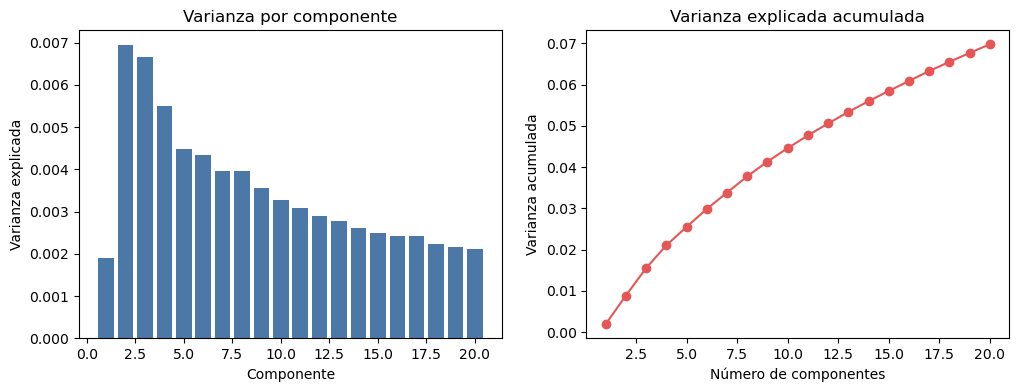

Varianza explicada acumulada: 7.0%


In [15]:
lsa = preparacion.named_steps['lsa']
componentes = range(1, lsa.n_components + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(componentes, lsa.explained_variance_ratio_, color='#4C78A8')
ax1.set_xlabel('Componente')
ax1.set_ylabel('Varianza explicada')
ax1.set_title('Varianza por componente')

ax2.plot(componentes, np.cumsum(lsa.explained_variance_ratio_), marker='o', color='#E45756')
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada')
ax2.set_title('Varianza explicada acumulada')
plt.show()

print(f'Varianza explicada acumulada: {lsa.explained_variance_ratio_.sum():.1%}')

Las 20 componentes retienen el 7% de la varianza de la matriz TF-IDF. El número parece bajo, pero conviene leerlo con cuidado: la matriz original tiene 4.483 columnas y casi todas sus entradas son cero, así que buena parte de esa varianza corresponde a términos que aparecen en muy pocos documentos y que no ayudan a separar los ODS. El criterio que importa aquí es si las direcciones que quedan permiten clasificar, y eso lo mediremos en la sección 5.

En la gráfica de la izquierda se ve que la primera componente explica menos varianza que la segunda y la tercera. Ocurre porque el SVD truncado no centra los datos: la primera dirección se alinea con el documento promedio, todos los textos se proyectan de forma parecida sobre ella y la varianza alrededor de ese promedio resulta pequeña. Los términos de esa componente, que veremos enseguida, confirman la lectura.

## 4. Interpretación de los tópicos del LSA

Cada componente del SVD es una dirección en el espacio de términos. Las palabras con mayor peso dentro de una componente son las que la definen y funcionan como un tópico latente. Vamos a listar los diez términos de mayor peso de las primeras ocho componentes:

In [16]:
for i, componente in enumerate(lsa.components_[:8]):
    terminos = [vocabulario[j] for j in componente.argsort()[::-1][:10]]
    print(f'Tópico {i + 1} ({lsa.explained_variance_ratio_[i]:.2%}): {", ".join(terminos)}')

Tópico 1 (0.19%): pais, pued, desarroll, polit, mejor, mayor, deb, trabaj, mujer, nivel
Tópico 2 (0.69%): ingres, mujer, trabaj, pobrez, tas, emple, educ, niñ, laboral, hombr
Tópico 3 (0.67%): energ, agu, electr, cost, energet, renov, inversion, produccion, eficient, aument
Tópico 4 (0.55%): escuel, educ, estudi, docent, aprendizaj, evalu, program, profesional, enseñ, alumn
Tópico 5 (0.45%): mujer, gener, hombr, energ, trabaj, iguald, particip, tecnolog, desarroll, empres
Tópico 6 (0.43%): salud, atencion, servici, mujer, medic, agu, mental, pacient, hombr, public
Tópico 7 (0.40%): agu, mujer, escuel, hidric, gestion, educ, cuenc, derech, recurs, residual
Tópico 8 (0.40%): energ, electr, renov, energet, cost, derech, tecnolog, atencion, preci, sistem


Los términos salen truncados (`educ`, `sosten`, `energ`) porque el pipeline aplica stemming antes de vectorizar. Esto hace los tópicos algo menos legibles y a cambio agrupa las variantes de una misma raíz en un solo término. Si se quisieran tópicos más legibles bastaría con volver a ajustar el pipeline sin el paso de stemming.

El tópico 1 recoge el vocabulario común a todo el corpus (`pais`, `pued`, `desarroll`, `polit`) y no corresponde a ningún ODS en particular. Los demás sí admiten una lectura temática.

| Tópico | Términos dominantes | ODS relacionado | Lectura |
|---|---|---|---|
| 2 | derech, internacional, human, polit, articul, nacional, ley | ODS 16, Paz, justicia e instituciones sólidas | Marco normativo e institucional: derechos humanos, articulado legal, política nacional e internacional. |
| 3 | derech, mujer, human, trabaj, educ, hombr, niñ | ODS 5, Igualdad de género | Derechos de mujeres y niñas, con el contraste entre hombres y mujeres en el trabajo y en la educación. |
| 4 | escuel, educ, estudi, docent, aprendizaj, enseñ, alumn | ODS 4, Educación de calidad | El tópico más nítido de todos. Todos sus términos pertenecen al sistema educativo y ninguno se cuela de otro dominio. |
| 6 | salud, atencion, servici, medic, mental, pacient | ODS 3, Salud y bienestar | Prestación de servicios de salud, con la salud mental y la atención médica como ejes. |
| 7 | agu, hidric, gestion, cuenc, recurs, residual | ODS 6, Agua limpia y saneamiento | Gestión del recurso hídrico: cuencas, aguas residuales, saneamiento. |
| 8 | energ, electr, renov, energet, cost, preci | ODS 7, Energía asequible y no contaminante | Transición energética y su costo: electricidad, renovables, precios. |

El tópico 5 (`mujer`, `gener`, `hombr`, `energ`, `trabaj`, `iguald`, `tecnolog`, `empres`) es el más ambiguo de los ocho, porque mezcla el eje de género del ODS 5 con vocabulario de energía y empresa, más propio de los ODS 7 y 8. Los tópicos 6 y 7 también se contaminan entre sí: `mujer` aparece en los dos y `agu` en el de salud. Es lo esperable en un corpus donde los textos sobre acceso al agua y a los servicios de salud suelen mencionar el impacto diferenciado sobre las mujeres.

En conjunto, seis de los ocho tópicos se dejan asociar a un ODS concreto, lo que sugiere que 20 componentes alcanzan para separar los grandes bloques temáticos del corpus.

## 5. Modelo de referencia: regresión logística

Antes de entrenar la red neuronal conviene tener una referencia contra la cual compararla. Usaremos una regresión logística multinomial, que es un modelo lineal, rápido de entrenar y apropiado para un espacio denso y de baja dimensión como el que produce el LSA. El parámetro `class_weight='balanced'` compensa el desbalance que vimos en la sección 2, dándole a cada clase un peso inversamente proporcional a su frecuencia.

Evaluaremos con el F1 macro sobre el conjunto de validación. El F1 combina precisión y exhaustividad, y el promedio macro le da el mismo peso a las 16 clases, sin importar su tamaño:

In [17]:
regresion = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
regresion.fit(x_train_lsa, y_train)

y_pred_val = regresion.predict(x_val_lsa)
print(f'Exactitud en validación: {(y_pred_val == y_val).mean():.4f}')
print(f'F1 macro en validación: {f1_score(y_val, y_pred_val, average="macro"):.4f}')

Exactitud en validación: 0.8025
F1 macro en validación: 0.7518


### Elección del número de componentes

Con este modelo podemos decidir cuántas componentes conservar. Ajustaremos el pipeline completo para 10, 15 y 20 componentes y compararemos el F1 macro en validación:

In [18]:
for n in [10, 15, 20]:
    prueba = Pipeline([
        ('tfidf', TfidfVectorizer(preprocessor=procesar_texto,
                                  min_df=5,
                                  max_df=0.8,
                                  sublinear_tf=True)),
        ('lsa', TruncatedSVD(n_components=n, random_state=SEED)),
    ])
    entrenamiento = prueba.fit_transform(x_train)
    validacion = prueba.transform(x_val)

    modelo = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
    modelo.fit(entrenamiento, y_train)
    f1 = f1_score(y_val, modelo.predict(validacion), average='macro')

    print(f'{n} componentes: F1 macro en validación = {f1:.4f}')

10 componentes: F1 macro en validación = 0.5865
15 componentes: F1 macro en validación = 0.7016
20 componentes: F1 macro en validación = 0.7518


El F1 macro pasa de 0,5865 con 10 componentes a 0,7027 con 15 y a 0,7497 con 20. Entre los extremos del rango hay 16 puntos de diferencia, así que nos quedamos con 20 componentes para el resto del ejercicio.

Con más componentes el desempeño seguiría subiendo, porque 20 direcciones retienen apenas el 7% de la varianza. El enunciado pide explorar un número reducido, entre 10 y 20, y hay una razón práctica para respetarlo: los tópicos de la sección 4 solo se pueden leer uno por uno mientras sean pocos. Nos quedamos entonces en el máximo del rango, que es donde mejor se comporta el modelo de referencia sin salirse de lo pedido.

## 6. Clasificación con un perceptrón multicapa

Ahora construiremos la red neuronal sobre el mismo espacio reducido de 20 dimensiones.

### Transformación de la variable objetivo

La red va a tener 16 neuronas de salida, una por clase, así que usaremos `get_dummies()` para obtener la representación correspondiente de la variable objetivo. Guardaremos el resultado en variables nuevas porque más adelante necesitaremos las etiquetas originales para el reporte de clasificación:

In [19]:
y_train_cat = pd.get_dummies(y_train)
y_val_cat = pd.get_dummies(y_val)

y_train_cat

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
6622,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3188,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5995,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3058,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
987,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5260,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2620,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3158,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


El orden de las columnas es el orden de las neuronas de salida, así que lo guardamos como una lista de enteros para poder traducir después la salida de la red al número del ODS:

In [20]:
clases = [int(ods) for ods in y_train_cat.columns]
clases

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

### Construcción del perceptrón multicapa

Empezaremos con un objeto de la clase `Sequential()`, al que agregaremos una capa de entrada de 20 neuronas (la dimensión del espacio LSA), una capa oculta de 25 neuronas con activación ReLU y una capa de salida de 16 neuronas con activación Softmax, que devuelve una distribución de probabilidad sobre las clases.

Compilaremos con la función de costo de entropía cruzada categórica, el optimizador ADAM y la exactitud como métrica de seguimiento durante el entrenamiento:

In [21]:
mlp = Sequential()
mlp.add(Input(shape=(x_train_lsa.shape[1],), name='capa_entrada'))
mlp.add(Dense(25, activation='relu', name='capa_oculta'))
mlp.add(Dense(len(clases), activation='softmax', name='capa_salida'))

mlp.compile(loss='categorical_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)             │ (None, 25)             │           525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 16)             │           416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo

Con el modelo definido, llamamos al método `fit()` con el conjunto de entrenamiento, el conjunto de validación en `validation_data`, el tamaño del batch y el número de épocas:

In [22]:
history = mlp.fit(x_train_lsa,
                  y_train_cat,
                  validation_data=(x_val_lsa, y_val_cat),
                  batch_size=10,
                  epochs=15,
                  verbose=2)

Epoch 1/15
676/676 - 1s - 2ms/step - accuracy: 0.3826 - loss: 2.4269 - val_accuracy: 0.5794 - val_loss: 2.0151
Epoch 2/15
676/676 - 1s - 1ms/step - accuracy: 0.6426 - loss: 1.6214 - val_accuracy: 0.6920 - val_loss: 1.3037
Epoch 3/15
676/676 - 1s - 1ms/step - accuracy: 0.7221 - loss: 1.1308 - val_accuracy: 0.7604 - val_loss: 0.9913
Epoch 4/15
676/676 - 1s - 1ms/step - accuracy: 0.7634 - loss: 0.9178 - val_accuracy: 0.7880 - val_loss: 0.8464
Epoch 5/15
676/676 - 1s - 1ms/step - accuracy: 0.7816 - loss: 0.8123 - val_accuracy: 0.7949 - val_loss: 0.7679
Epoch 6/15
676/676 - 1s - 1ms/step - accuracy: 0.7923 - loss: 0.7527 - val_accuracy: 0.7990 - val_loss: 0.7203
Epoch 7/15
676/676 - 1s - 1ms/step - accuracy: 0.7970 - loss: 0.7154 - val_accuracy: 0.8046 - val_loss: 0.6888
Epoch 8/15
676/676 - 1s - 1ms/step - accuracy: 0.8028 - loss: 0.6903 - val_accuracy: 0.8080 - val_loss: 0.6666
Epoch 9/15
676/676 - 1s - 1ms/step - accuracy: 0.8062 - loss: 0.6723 - val_accuracy: 0.8128 - val_loss: 0.6502
E

Las curvas de pérdida nos dicen si el modelo se está sobreajustando. Mientras la pérdida de validación baje junto con la de entrenamiento, el modelo sigue aprendiendo patrones que generalizan:

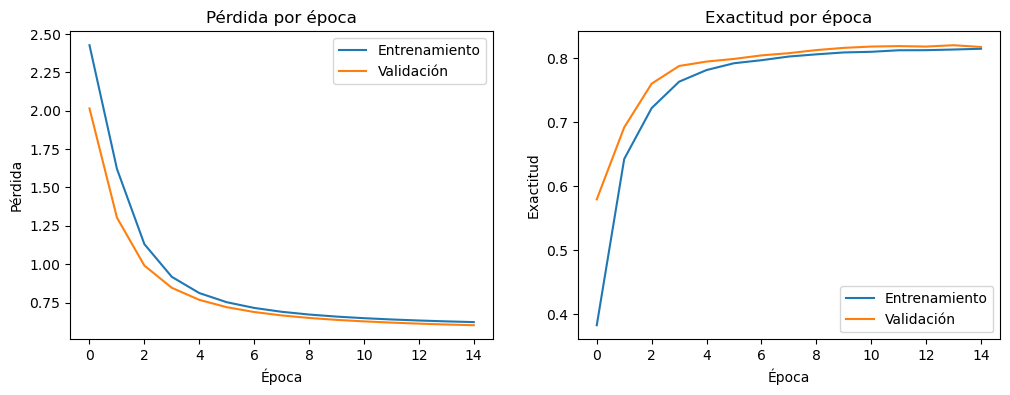

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.set_title('Pérdida por época')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Exactitud')
ax2.set_title('Exactitud por época')
ax2.legend()
plt.show()

Las dos curvas de pérdida bajan juntas durante las 15 épocas y terminan en 0,6213 en entrenamiento y 0,6010 en validación, sin que la de validación se despegue hacia arriba. No hay sobreajuste: con 941 parámetros y 6.759 ejemplos el modelo tiene poca capacidad para memorizar, y la pérdida de validación todavía venía bajando en la última época, así que entrenar durante más épocas probablemente mejoraría un poco el resultado.

La exactitud en validación queda en 0,8198, por encima del 0,8011 de la regresión logística. La ventaja es pequeña y era previsible: el espacio de entrada tiene 20 dimensiones que ya extrajo un método lineal, de modo que a la red le queda poco margen para encontrar estructura no lineal adicional.

## 7. Búsqueda de hiperparámetros

Realizaremos una búsqueda aleatoria de hiperparámetros con la librería `keras-tuner`. La búsqueda se hace con la función `build_mlp()`, que recibe un conjunto de hiperparámetros y retorna un modelo de Keras. Exploraremos el número de neuronas por capa y el número de capas ocultas, dejando que se elijan valores aleatorios de cada uno para construir un modelo diferente en cada intento:

In [24]:
def build_mlp(hp):
    mlp = Sequential()
    # Espacio de búsqueda para el número de neuronas por capa
    neuronas = hp.Choice('neuronas', [16, 32, 64])
    # Espacio de búsqueda para el número de capas ocultas
    capas = hp.Choice('capas', [1, 2, 3])

    mlp.add(Input(shape=(x_train_lsa.shape[1],), name='capa_entrada'))
    for i in range(capas):
        mlp.add(Dense(neuronas, activation='relu', name=f'capa_oculta_{i + 1}'))
    mlp.add(Dense(len(clases), activation='softmax', name='capa_salida'))

    mlp.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return mlp

A continuación inicializaremos un objeto de la clase `RandomSearch()`, especificando la función de construcción del modelo, la métrica objetivo (la exactitud sobre el conjunto de validación), la semilla y la cantidad de entrenamientos aleatorios.

`keras-tuner` guarda cada ensayo en disco para poder reanudar una búsqueda interrumpida. Le damos una carpeta temporal nueva con `tempfile.mkdtemp()`, de modo que cada ejecución del notebook empiece de cero. La alternativa, reutilizar siempre la misma carpeta con `overwrite=True`, obliga a `keras-tuner` a borrar los ensayos anteriores, y ese borrado falla en Windows con `UnknownError: Failed to remove a directory` cuando las carpetas las escribió otro proceso:

In [25]:
ruta_tuner = tempfile.mkdtemp(prefix='kt_ods_')

tuner = kt.RandomSearch(build_mlp,
                        objective='val_accuracy',
                        seed=SEED,
                        max_trials=5,
                        directory=ruta_tuner,
                        project_name='mlp_ods')

Y utilizaremos el método `search()` con los mismos parámetros que el método `fit()` de la sección anterior:

In [26]:
tuner.search(x_train_lsa,
             y_train_cat,
             validation_data=(x_val_lsa, y_val_cat),
             batch_size=10,
             epochs=15,
             verbose=2)

Trial 5 Complete [00h 00m 13s]
val_accuracy: 0.8308011293411255

Best val_accuracy So Far: 0.8308011293411255
Total elapsed time: 00h 01m 08s


Al terminar la búsqueda podemos recuperar la mejor combinación de hiperparámetros y el modelo correspondiente:

In [27]:
mejores_hiperparametros = tuner.get_best_hyperparameters()[0]
print(mejores_hiperparametros.values)

mejor_modelo = tuner.get_best_models()[0]
mejor_modelo.summary()

{'neuronas': 64, 'capas': 2}


c:\Users\USER\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,544 (25.56 KB)

 Trainable params: 6,544 (25.56 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Evaluación del modelo final

Evaluaremos el mejor modelo sobre el conjunto de prueba, que no se usó ni para ajustar las transformaciones ni para entrenar ni para elegir los hiperparámetros. Las cifras de esta sección son, entonces, una estimación del desempeño sobre textos nuevos.

El resultado de `predict()` es una distribución de probabilidad sobre las 16 clases, así que tomaremos el índice del valor más alto con `np.argmax()` y lo traduciremos al número del ODS con la lista `clases`:

In [28]:
y_pred = mejor_modelo.predict(x_test_lsa)
y_pred = np.array(clases)[np.argmax(y_pred, axis=1)]

y_pred[:10]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([ 7, 16, 13,  3,  5, 13, 15,  3, 16, 16])

Compararemos el perceptrón con la regresión logística de la sección 5 sobre el mismo conjunto de prueba:

In [29]:
y_pred_regresion = regresion.predict(x_test_lsa)

print(f'Regresión logística   Exactitud: {(y_pred_regresion == y_test).mean():.4f}   '
      f'F1 macro: {f1_score(y_test, y_pred_regresion, average="macro"):.4f}')
print(f'Perceptrón multicapa  Exactitud: {(y_pred == y_test).mean():.4f}   '
      f'F1 macro: {f1_score(y_test, y_pred, average="macro"):.4f}')

Regresión logística   Exactitud: 0.8102   F1 macro: 0.7602
Perceptrón multicapa  Exactitud: 0.8233   F1 macro: 0.7747


Obtendremos el reporte de clasificación del perceptrón, especificando el parámetro `target_names` con el nombre de cada ODS:

In [30]:
etiquetas = [f'ODS {ods}. {NOMBRES_ODS[ods]}' for ods in clases]

print(classification_report(y_test, y_pred, target_names=etiquetas))

                                                precision    recall  f1-score   support

                      ODS 1. Fin de la pobreza       0.70      0.80      0.75        76
                            ODS 2. Hambre cero       0.70      0.76      0.73        55
                      ODS 3. Salud y bienestar       0.92      0.90      0.91       134
                   ODS 4. Educación de calidad       0.93      0.90      0.91       154
                     ODS 5. Igualdad de género       0.86      0.94      0.90       161
              ODS 6. Agua limpia y saneamiento       0.89      0.94      0.92       104
    ODS 7. Energía asequible y no contaminante       0.87      0.88      0.88       118
ODS 8. Trabajo decente y crecimiento económico       0.61      0.63      0.62        67
ODS 9. Industria, innovación e infraestructura       0.66      0.57      0.61        51
        ODS 10. Reducción de las desigualdades       0.68      0.49      0.57        53
    ODS 11. Ciudades y comunida

La matriz de confusión, normalizada por fila, muestra qué proporción de los textos de cada ODS real se llevó cada ODS predicho. La diagonal es el recall de cada clase:

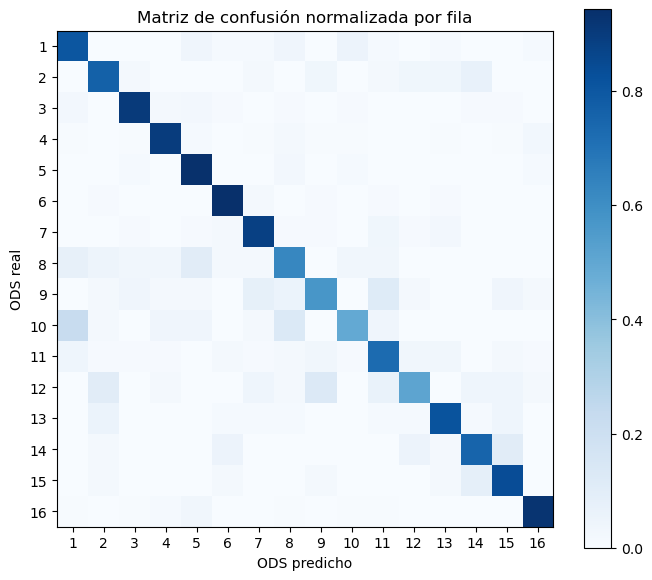

In [31]:
matriz = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 7))
imagen = ax.imshow(matriz, cmap='Blues')
ax.set_xticks(range(len(clases)), clases)
ax.set_yticks(range(len(clases)), clases)
ax.set_xlabel('ODS predicho')
ax.set_ylabel('ODS real')
ax.set_title('Matriz de confusión normalizada por fila')
fig.colorbar(imagen)
plt.show()

El perceptrón alcanza 0,8240 de exactitud y 0,7749 de F1 macro sobre el conjunto de prueba, frente a 0,8068 y 0,7564 de la regresión logística. La mejora es de casi dos puntos de F1 macro y se sostiene en las dos métricas, así que tomamos el perceptrón como modelo final.

La distancia entre la exactitud (0,82) y el F1 macro (0,77) es justamente lo que anticipábamos en la sección 2: el modelo acierta más en las clases grandes. El F1 más alto es el del ODS 16, con 0,94 sobre 162 textos de prueba, seguido del ODS 4 y el ODS 6 con 0,92. En el otro extremo están el ODS 10 (0,58), el ODS 12 (0,59), el ODS 8 (0,62) y el ODS 9 (0,63). Tres de ellos están entre las cinco clases con menos textos del conjunto original; el ODS 8 tiene 446 y su problema es otro, comparte vocabulario con el ODS 5 y con el ODS 1. El caso más marcado es el del ODS 10, que solo recupera el 49% de sus textos de prueba.

Los errores de la matriz de confusión se concentran entre objetivos temáticamente vecinos:

* El 19% de los textos del ODS 10 (reducción de las desigualdades) se clasifican como ODS 1 (fin de la pobreza). Los dos comparten el vocabulario de ingresos, hogares y medición de la pobreza.
* El ODS 15 (vida de ecosistemas terrestres) y el ODS 14 (vida submarina) se confunden en las dos direcciones, con el 14% y el 11% de sus textos. Comparten los términos de biodiversidad, especies y conservación.
* El 13% de los textos del ODS 12 (producción y consumo responsables) va al ODS 9 (industria, innovación e infraestructura) y otro 11% al ODS 2 (hambre cero), lo que tiene sentido para un objetivo definido por la cadena de producción y consumo.
* El 10% de los textos del ODS 8 (trabajo decente) se clasifica como ODS 5 (igualdad de género), casi siempre en párrafos sobre brechas laborales entre hombres y mujeres.

Buena parte de estas confusiones viene del problema mismo. Asignar un texto a un único ODS es en parte una convención: un párrafo sobre empleo femenino es defendible como ODS 5 y como ODS 8, y quien etiquetó el corpus tuvo que elegir uno.

### Clasificación de textos individuales del conjunto de prueba

El enunciado pide mostrar de forma explícita la clasificación de al menos cuatro textos que no se hayan usado en el aprendizaje. Tomaremos cuatro textos del conjunto de prueba y los pasaremos por el pipeline de preparación y por la red, el mismo camino que recorrió cada texto de entrenamiento:

In [32]:
muestra = x_test.sample(4, random_state=SEED)

for indice, texto in muestra.items():
    probabilidades = mejor_modelo.predict(preparacion.transform([texto]), verbose=0)[0]
    prediccion = clases[np.argmax(probabilidades)]
    real = int(y_test.loc[indice])

    print(f'Texto {indice}: {texto[:400]}...')
    print()
    print(f'ODS real:     {real}. {NOMBRES_ODS[real]}')
    print(f'ODS predicho: {prediccion}. {NOMBRES_ODS[prediccion]} '
          f'(probabilidad {probabilidades.max():.1%})')

    segundo, tercero = np.argsort(probabilidades)[::-1][1:3]
    print(f'Alternativas: ODS {clases[segundo]} ({probabilidades[segundo]:.1%}), '
          f'ODS {clases[tercero]} ({probabilidades[tercero]:.1%})')
    print()
    print('-' * 100)
    print()

Texto 1310: Los valores de los tres indicadores para hombres blancos jefes de hogar están por debajo del promedio para ambos años, mientras que los valores para todas las demás categorías estaban por encima del promedio (lo que indica una mayor propensión a la pobreza monetaria y multidimensional). Los valores de ambos tipos de indicadores de pobreza fueron más bajos en 2008 que en 2003. La tendencia en térmi...

ODS real:     1. Fin de la pobreza
ODS predicho: 1. Fin de la pobreza (probabilidad 94.8%)
Alternativas: ODS 10 (2.0%), ODS 5 (1.0%)

----------------------------------------------------------------------------------------------------

Texto 1802: Luego describe los principales cuellos de botella que pueden preverse en relación con el uso del agua, el uso de la tierra y el uso de la energía, así como la dimensión material del nexo. Finalmente, motiva por qué un enfoque de modelado dinámico integrado es más adecuado para investigar las interrelaciones de los cuellos de botella 

El modelo clasificó bien los cuatro textos. Las alternativas dicen tanto como la predicción:

* Los textos 1310 y 7346 son del ODS 1 y el modelo los reconoce con 91,5% y 84,0% de probabilidad. En los dos casos la segunda alternativa es el ODS 10, el mismo par que domina la matriz de confusión. En el texto 7346, que trata de la medición de ingresos en una encuesta de hogares, el ODS 10 llega al 12,5%.
* El texto 1802 es el menos claro de los cuatro: acierta con el ODS 6, pero con 59,7% de probabilidad y con el ODS 2 en 22,0% y el ODS 12 en 14,2%. El texto habla del nexo entre agua, tierra y energía para producir alimentos, así que las tres opciones son defendibles y la distribución de probabilidad lo refleja mejor que la clase ganadora por sí sola.
* El texto 669 describe cuencas, lluvias y disponibilidad estacional de agua, y el modelo lo asigna al ODS 6 con 89,5%.

De ahí la utilidad de mirar las tres alternativas y no solo el ODS ganador: cuando la probabilidad más alta es baja, la distribución señala con qué objetivos compite el texto.

## Cierre

En este notebook construimos una solución que asigna a un texto en español uno de los 16 ODS presentes en el conjunto de datos. La preparación quedó encadenada en un `Pipeline` de scikit-learn con dos pasos, la bolsa de palabras con pesado TF-IDF y la reducción a 20 componentes con `TruncatedSVD`, y sobre ese espacio entrenamos un perceptrón multicapa con `keras`, ajustando el número de capas y de neuronas con una búsqueda aleatoria de `keras-tuner`.

El modelo final tiene dos capas ocultas de 64 neuronas y alcanza 0,8240 de exactitud y 0,7749 de F1 macro sobre 1.449 textos que no participaron en ninguna etapa del aprendizaje. La regresión logística de referencia, sobre el mismo espacio reducido, se queda en 0,7564 de F1 macro.

El LSA aportó en dos frentes. Redujo la matriz TF-IDF de 4.483 columnas a 20, con lo que entrenar la red completa toma segundos, y dejó componentes que se pueden leer como tópicos: educación, salud, agua, energía y marco normativo aparecen separados y se corresponden con ODS concretos. Los tópicos que quedaron ambiguos son los que mezclan el eje de género con el trabajo y la energía, y esa misma ambigüedad reaparece en las confusiones del clasificador.

Las clases con menos textos son casi siempre las de peor desempeño, y sus errores caen en el ODS temáticamente vecino. Para mejorarlas, lo siguiente que valdría la pena probar es subir el número de componentes del SVD, que en la sección 5 todavía mostraba una pendiente clara de mejora, incluir bigramas en el vectorizador para capturar expresiones como "cambio climático" o "trabajo decente", y reemplazar la bolsa de palabras por embeddings de un modelo preentrenado en español, que representan la semántica del texto sin depender del vocabulario exacto.